# IMPORTING LIBRARIES

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [30]:
data=pd.read_csv(r"C:\Retail_pulse\RetailPulse-AI-Powered-Customer-Analytics-Demand-Forecasting\data\raw\OnlineRetail.csv",encoding='latin1')  #ADD PATH ACCORDINGLY
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [31]:
df=data.copy()
df.info()
df.describe()
df.isnull().sum()
# df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [32]:
print(f"length of dataset: {len(df)}")
print(f"no of columns: {len(df.columns)}")


length of dataset: 541909
no of columns: 8


In [33]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': miss, 'Missing %': pct})
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n[{name}] — {len(summary)} columns with nulls')
    display(summary)
missing_summary(df, 'Original Data')


[Original Data] — 2 columns with nulls


,Missing Count,Missing %
CustomerID,135080,24.93
Description,1454,0.27


# CLEANING OF DATASET 

In [34]:
invoice_to_customer = (
    df.dropna(subset=['CustomerID'])
    .groupby('InvoiceNo')['CustomerID']
    .first()
)
df['CustomerID'] = df['CustomerID'].fillna(df['InvoiceNo'].map(invoice_to_customer))
df['CustomerID'] = df['CustomerID'].fillna(-1).astype(int)
print(df['CustomerID'].isnull().sum())

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M").dt.date
df["Revenue"] = (df["Quantity"] * df["UnitPrice"]).round(2)
df["CustomerID"] = df["CustomerID"].astype(int)
print(f"Clean rows : {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products : {df['StockCode'].nunique():,}")

print(f"Date range  : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

0
Clean rows : 530,104
Unique customers: 4,339
Unique products : 3,922
Date range  : 2010-12-01 → 2011-12-09


# EXPLORATORY DATA ANALYSIS (EDA) STEPS => 
1.) How many times different customers visited
2.) Which products were bought the most
3.) Product demand by country

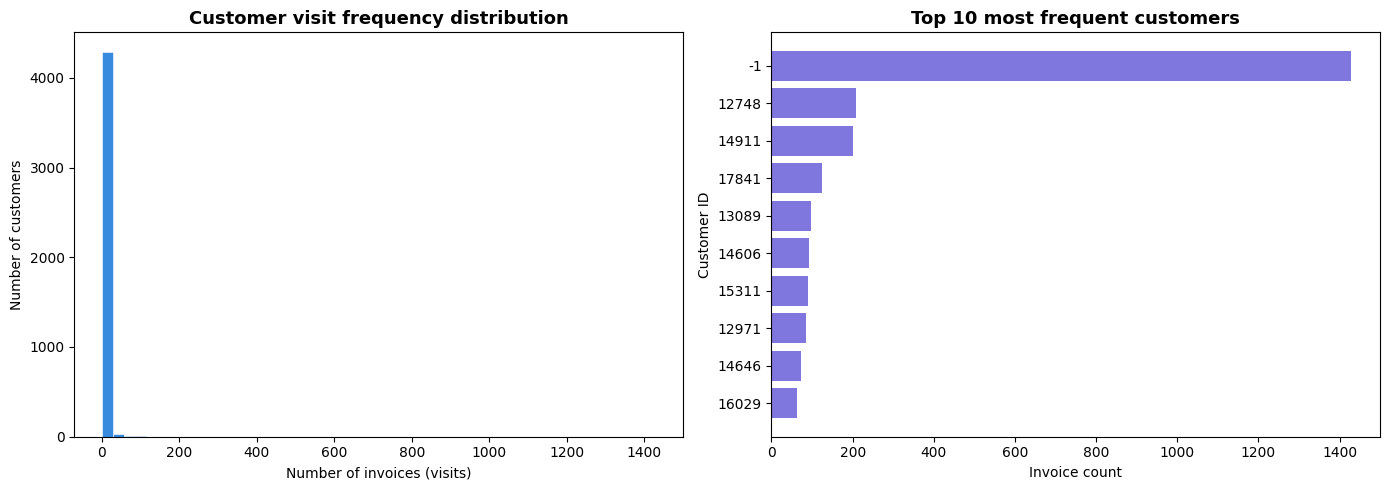

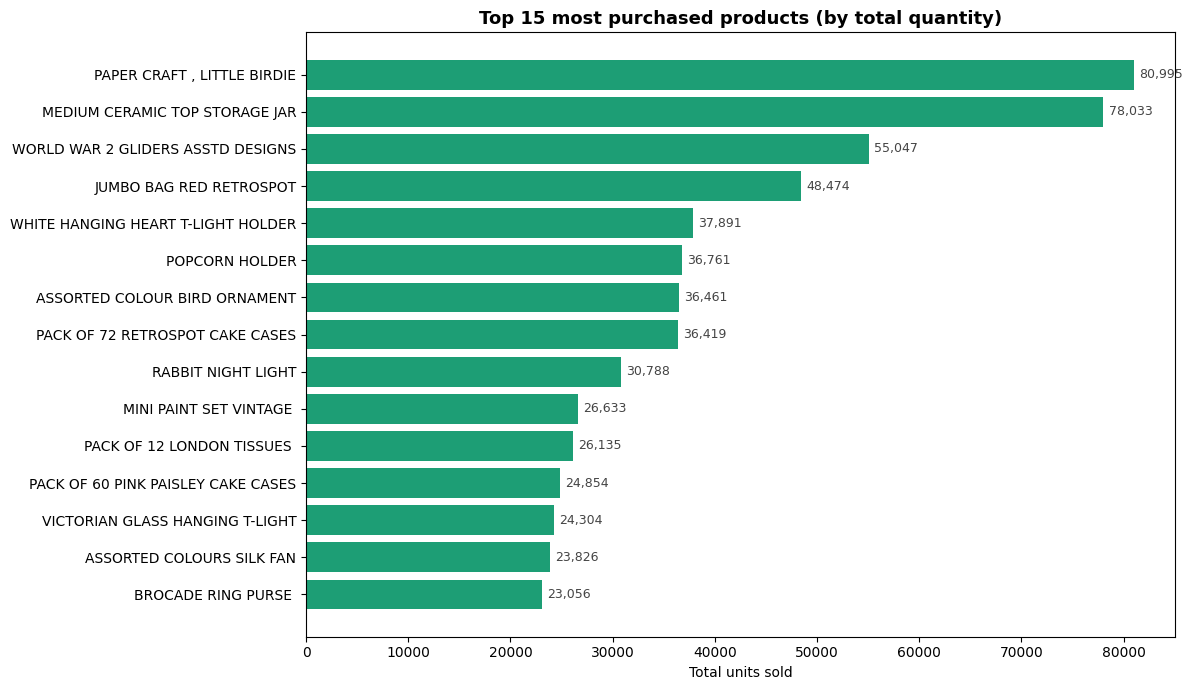

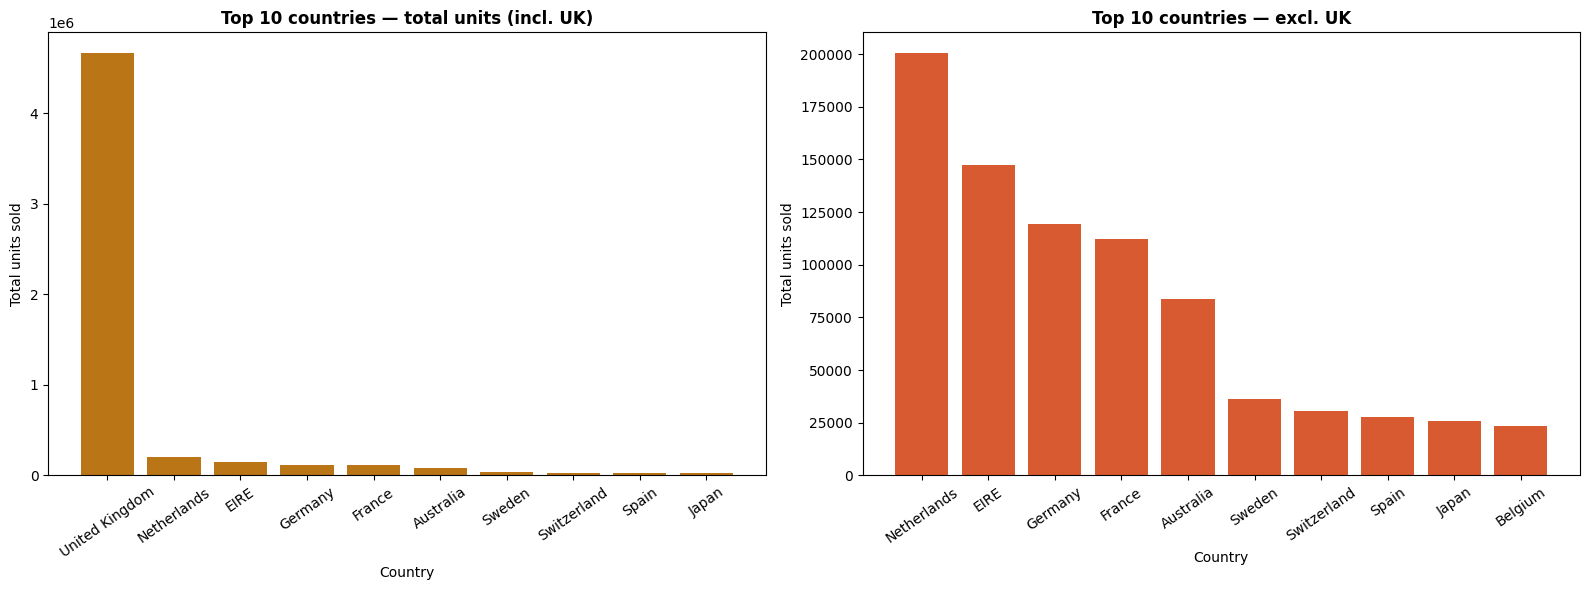

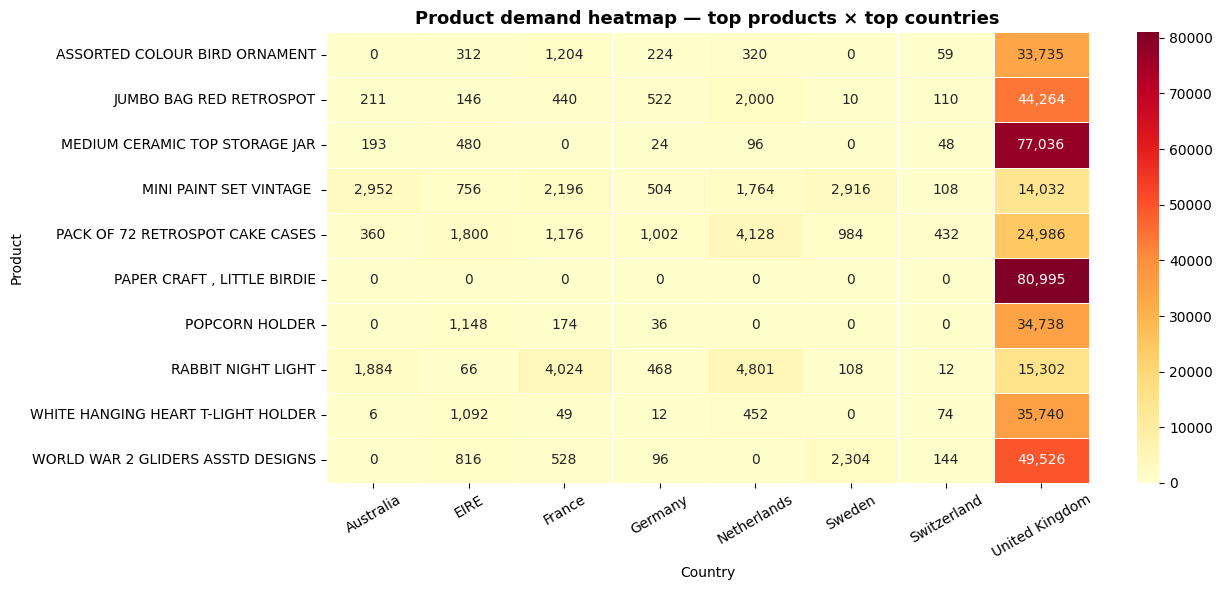


── Spend summary ──────────────────────────
Total revenue : £10,666,685
Mean spend : £2,458
Median spend : £675
Top spender: Customer -1.0 — £1,755,277


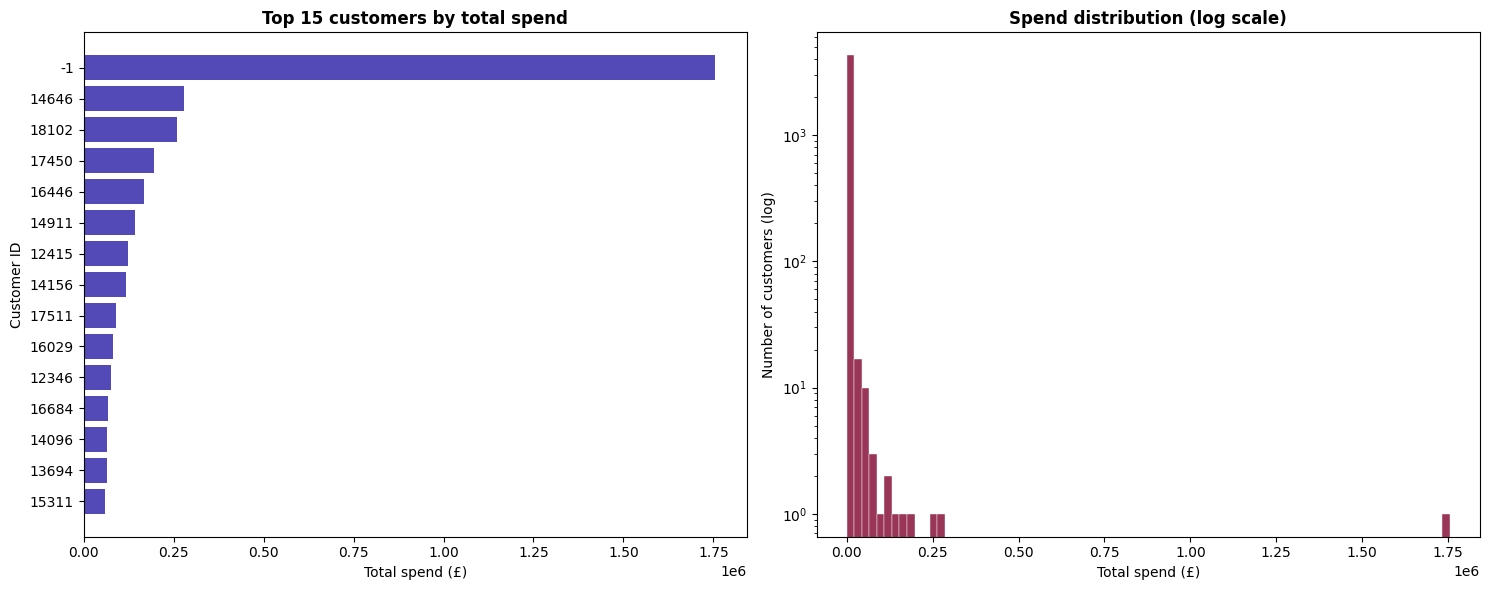

In [35]:
#####################################################   
# CHART 1 — How many times different customers visited (invoice count)
#####################################################  

visits_per_customer = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "visit_count"})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    visits_per_customer["visit_count"],
    bins=50, color="#378ADD", edgecolor="white", linewidth=0.4
)
axes[0].set_title("Customer visit frequency distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of invoices (visits)")
axes[0].set_ylabel("Number of customers")

top_customers = visits_per_customer.nlargest(10, "visit_count")
axes[1].barh(
    top_customers["CustomerID"].astype(str),
    top_customers["visit_count"],
    color="#7F77DD"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 most frequent customers", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Invoice count")
axes[1].set_ylabel("Customer ID")

plt.tight_layout()
plt.show()

##################################################
#  CHART 2 — Which products were bought the most
##########################################

top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .nlargest(15)
    .sort_values()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top_products["Description"],
    top_products["Quantity"],
    color="#1D9E75"
)
ax.set_title("Top 15 most purchased products (by total quantity)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total units sold")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 500, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va="center", fontsize=9, color="#444")

plt.tight_layout()
plt.show()

#####################################################  
#  CHART 3 — Product demand by country
#####################################################  

units_by_country = (
    df.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_countries_all = units_by_country.head(10)
axes[0].bar(
    top_countries_all["Country"],
    top_countries_all["Quantity"],
    color="#BA7517"
)
axes[0].set_title("Top 10 countries — total units (incl. UK)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Total units sold")
axes[0].tick_params(axis="x", rotation=35)

no_uk = units_by_country[units_by_country["Country"] != "United Kingdom"].head(10)
axes[1].bar(
    no_uk["Country"],
    no_uk["Quantity"],
    color="#D85A30"
)
axes[1].set_title("Top 10 countries — excl. UK", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Total units sold")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

#####################################################  
# 3b — Heatmap: top 10 products × top 8 countries
#####################################################  

top8_countries = units_by_country.head(8)["Country"].tolist()
top10_prods    = (
    df.groupby("Description")["Quantity"]
    .sum().nlargest(10).index.tolist()
)
pivot = (
    df[df["Country"].isin(top8_countries) & df["Description"].isin(top10_prods)]
    .groupby(["Description", "Country"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=",",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Product demand heatmap — top products × top countries", fontsize=13, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Product")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#####################################################  
# CHART 4 — Total spent by customers
#####################################################  

spend_per_customer = (
    df.groupby("CustomerID")["Revenue"].sum().reset_index().rename(columns={"Revenue": "total_spend"}).sort_values("total_spend", ascending=False)
)

print("\n── Spend summary ──────────────────────────")
print(f"Total revenue : £{spend_per_customer['total_spend'].sum():,.0f}")
print(f"Mean spend : £{spend_per_customer['total_spend'].mean():,.0f}")
print(f"Median spend : £{spend_per_customer['total_spend'].median():,.0f}")
print(f"Top spender: Customer {spend_per_customer.iloc[0]['CustomerID']} "
      f"— £{spend_per_customer.iloc[0]['total_spend']:,.0f}")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top15_spenders = spend_per_customer.head(15).copy()
top15_spenders["CustomerID"] = top15_spenders["CustomerID"].astype(str)
axes[0].barh(
    top15_spenders["CustomerID"],
    top15_spenders["total_spend"],
    color="#534AB7"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 customers by total spend", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total spend (£)")
axes[0].set_ylabel("Customer ID")

axes[1].hist(
    spend_per_customer["total_spend"],
    bins=80,
    color="#993556",
    edgecolor="white",
    linewidth=0.3
)
axes[1].set_yscale("log")
axes[1].set_title("Spend distribution (log scale)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Total spend (£)")
axes[1].set_ylabel("Number of customers (log)")
plt.tight_layout()
plt.show()


# CLEANING OF THE DESCRIPTION COLUMN OF THE DATAFRAME 
KEY IDEA => USED STOCKCODE FOR REPLACING THE NON-NULL VALUES
2.)=> TEHRE WERE 112 DESCRIPTIONS REMAINING THAT HAVE ALL CORRESPONDING STOCK CODES WITH ALL NULL VALUES.
3.)=>REPLACED THEM WITH  ==>> unknown<stock code>


In [36]:
# Fill description using StockCode → known description map
code_to_desc = (
    df.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0])  
)
df['Description'] = df['Description'].fillna(df['StockCode'].map(code_to_desc))

# Hardcode known service codes
manual_map = {
    'POST': 'Postage', 'DOT': 'Dotcom Postage', 'M': 'Manual Entry',
    'BANK CHARGES': 'Bank Charges', 'AMAZONFEE': 'Amazon Fee',
    'C2': 'Carriage', 'S': 'Sample', 'CRUK': 'CRUK Commission'
}
df['Description'] = df['Description'].fillna(df['StockCode'].map(manual_map))

#  Label remaining as UNKNOWN
df['Description'] = df['Description'].fillna('UNKNOWN_' + df['StockCode'].astype(str))
print(df['Description'].isnull().sum())  

0


In [37]:
df.to_csv(r"C:\Retail_pulse\RetailPulse-AI-Powered-Customer-Analytics-Demand-Forecasting\data\processed\cleaned_retail_data.csv", index=False)

# OUTLIER DETECTION AND COMPARISON


 IQR Outliers — Quantity
Q1=1.00  Q3=10.00  IQR=9.00
Lower fence : -12.50
Upper fence : 23.50
Outlier rows: 56,363  (10.6%)

 IQR Outliers — UnitPrice
Q1=1.25  Q3=4.13  IQR=2.88
Lower fence : -3.07
Upper fence : 8.45
Outlier rows: 37,999  (7.2%)

 IQR Outliers — Revenue
Q1=3.75  Q3=17.70  IQR=13.95
Lower fence : -17.17
Upper fence : 38.62
Outlier rows: 42,651  (8.0%)

 Z-Score Outliers (|z| > 3)
Quantity : 522 rows
UnitPrice : 784 rows
Revenue : 535 rows

── Capping: Quantity ──────────────────────────
 5th  percentile (lower cap) : 1.00
95th percentile (upper cap) : 30.00
Before — min: 1.00  max: 80995.00
After— min: 1.00  max: 30.00

── Capping: UnitPrice ──────────────────────────
 5th  percentile (lower cap) : 0.42
95th percentile (upper cap) : 9.95
Before — min: 0.00  max: 13541.33
After— min: 0.42  max: 9.95

── Capping: Revenue ──────────────────────────
 5th  percentile (lower cap) : 1.25
95th percentile (upper cap) : 59.70
Before — min: 0.00  max: 168469.60
After— min: 1.25  

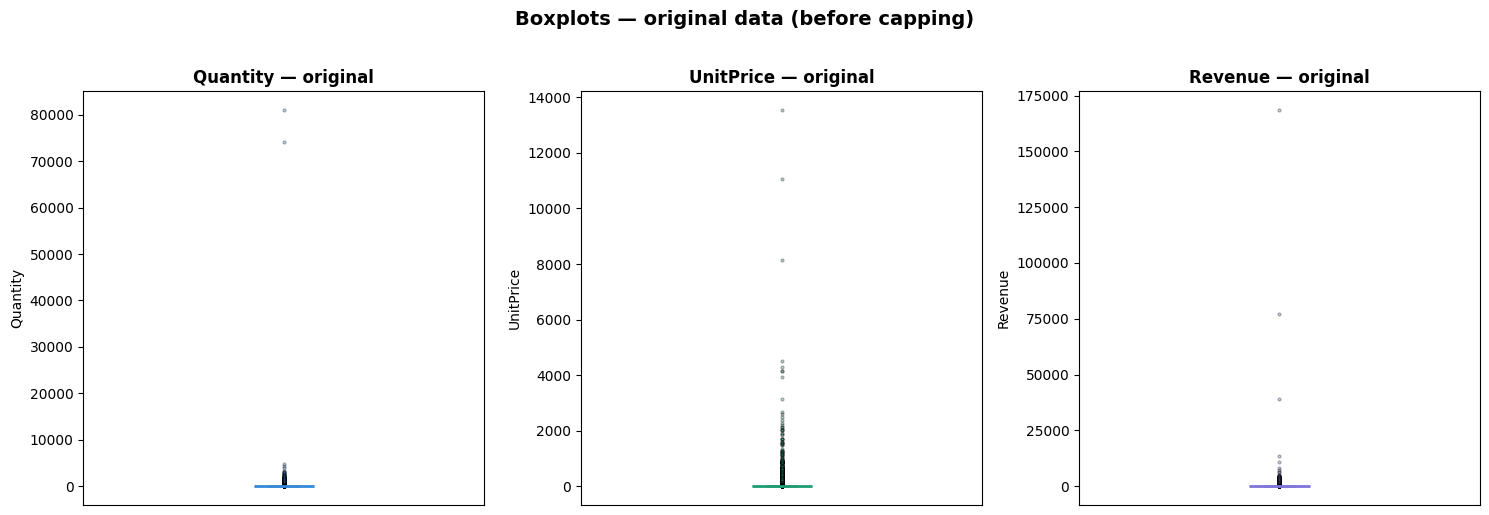

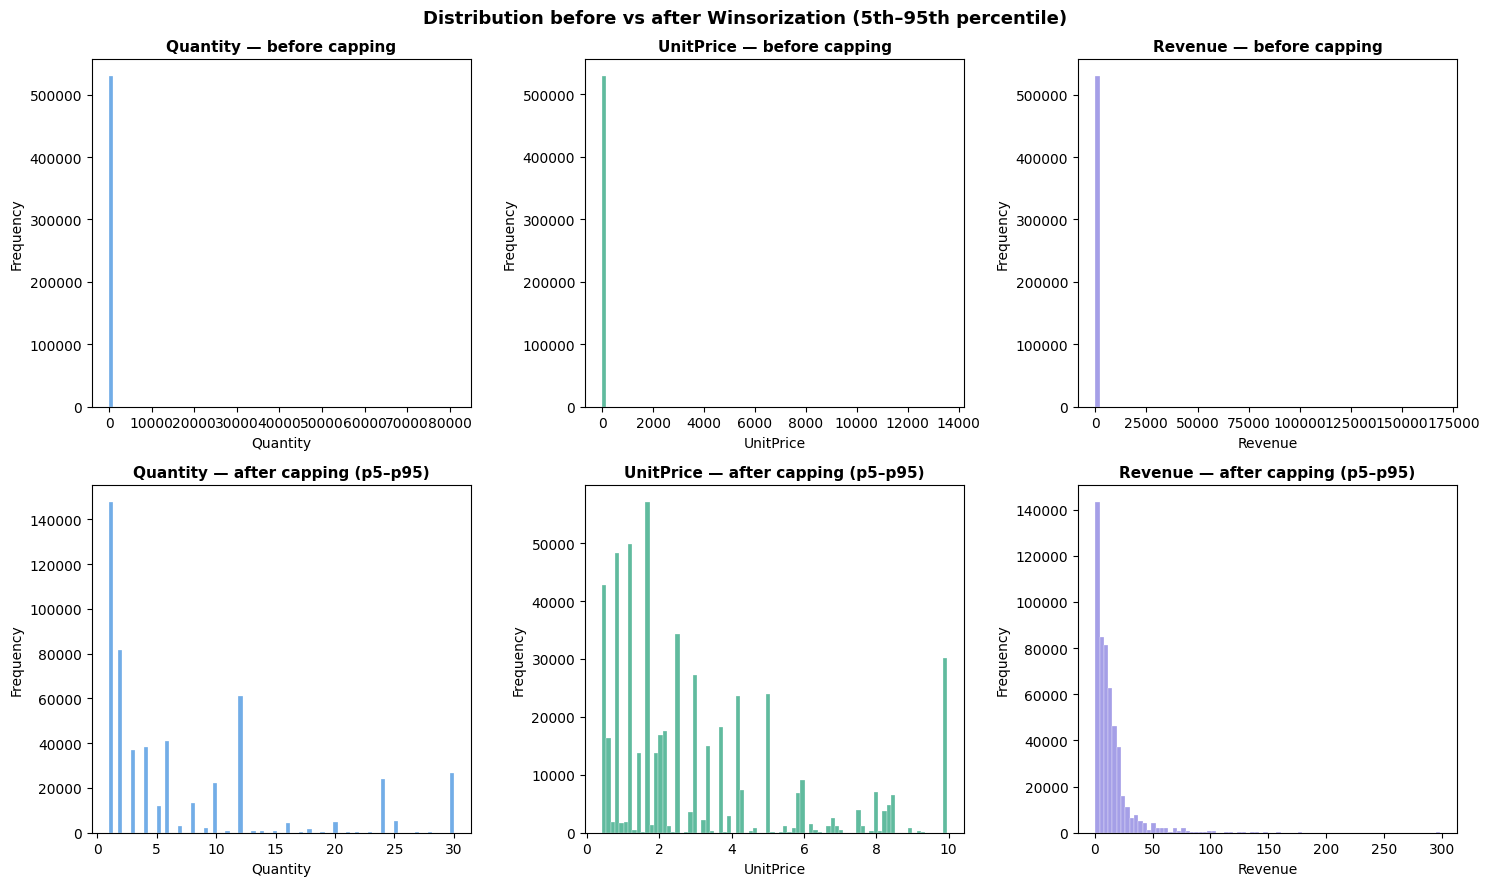

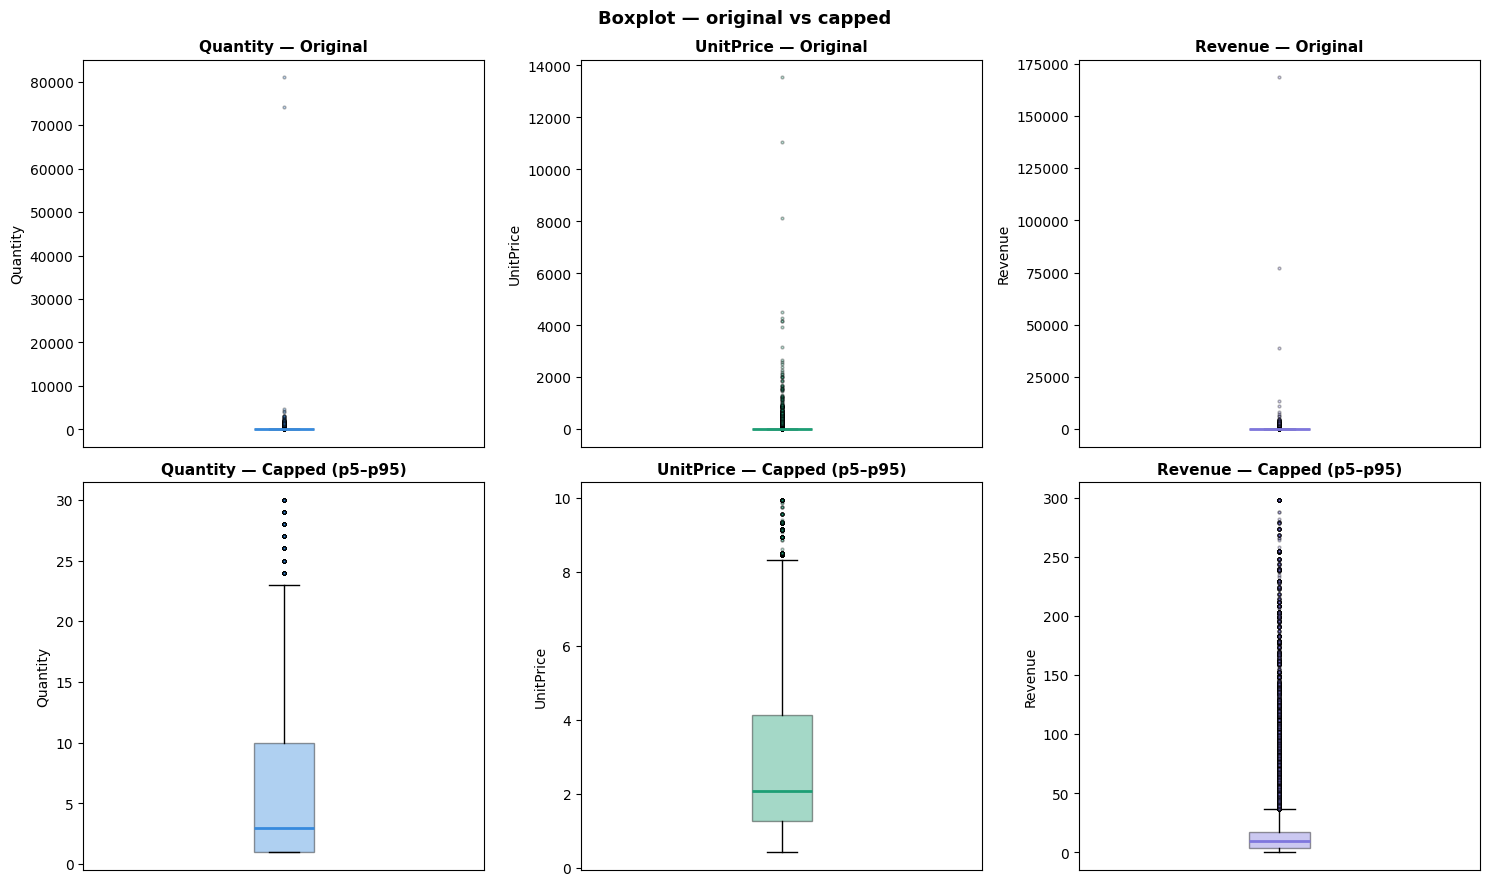


OUTLIER SUMMARY (Winsorization)
Total rows (before) : 530,104
Total rows (after) : 530,104
IQR outliers (Quantity) : 56,363  (10.6%)
IQR outliers (UnitPrice) : 37,999  (7.2%)
IQR outliers (Revenue) : 42,651  (8.0%)
  Capping applied at: 5th & 95th percentile


In [38]:
from scipy.stats.mstats import winsorize

#####################################################
# METHOD 1 — IQR (Interquartile Range) 
#####################################################

def iqr_outliers(series, label):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"\n IQR Outliers — {label}")
    print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"Lower fence : {lower:.2f}")
    print(f"Upper fence : {upper:.2f}")
    print(f"Outlier rows: {len(outliers):,}  ({len(outliers)/len(series)*100:.1f}%)")
    return lower, upper, outliers
qty_lower,  qty_upper,  qty_out = iqr_outliers(df["Quantity"],  "Quantity")
price_lower,price_upper,price_out= iqr_outliers(df["UnitPrice"], "UnitPrice")
rev_lower,  rev_upper,  rev_out = iqr_outliers(df["Revenue"],   "Revenue")

#####################################################
# METHOD 2 — Z-Score 
#####################################################
df["z_quantity"]  = np.abs(stats.zscore(df["Quantity"]))
df["z_unitprice"] = np.abs(stats.zscore(df["UnitPrice"]))
df["z_revenue"]   = np.abs(stats.zscore(df["Revenue"]))
THRESH = 3
z_qty_out   = df[df["z_quantity"]  > THRESH]
z_price_out = df[df["z_unitprice"] > THRESH]
z_rev_out   = df[df["z_revenue"]   > THRESH]
print(f"\n Z-Score Outliers (|z| > {THRESH})")
print(f"Quantity : {len(z_qty_out):,} rows")
print(f"UnitPrice : {len(z_price_out):,} rows")
print(f"Revenue : {len(z_rev_out):,} rows")

#####################################################
# WINSORIZATION — 5th aur 95th pe capping.
#to protect data exhaust.
#####################################################

df_capped = df.copy()

LOWER_PCT = 0.05   # 5th percentile
UPPER_PCT = 0.05   # 95th percentile 
cols_to_cap = ["Quantity", "UnitPrice", "Revenue"]
for col in cols_to_cap:
    p05 = df_capped[col].quantile(LOWER_PCT)
    p95 = df_capped[col].quantile(1 - UPPER_PCT)
    df_capped[col] = df_capped[col].clip(lower=p05, upper=p95)
    print(f"\n── Capping: {col} ──────────────────────────")
    print(f" 5th  percentile (lower cap) : {p05:.2f}")
    print(f"95th percentile (upper cap) : {p95:.2f}")
    print(f"Before — min: {df[col].min():.2f}  max: {df[col].max():.2f}")
    print(f"After— min: {df_capped[col].min():.2f}  max: {df_capped[col].max():.2f}")

# Revenue recalculate karo capped values se
df_capped["Revenue"] = df_capped["Quantity"] * df_capped["UnitPrice"]

print(f"\n  Rows before : {len(df):,}")
print(f"Rows after: {len(df_capped):,}")

#####################################################
# CHART 1 — Boxplots: original data
#####################################################

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols   = ["Quantity", "UnitPrice", "Revenue"]
colors = ["#378ADD", "#1D9E75", "#7F77DD"]

for ax, col, color in zip(axes, cols, colors):
    ax.boxplot(
        df[col],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4),
        medianprops=dict(color=color, linewidth=2),
        flierprops=dict(marker="o", markersize=2,
                        markerfacecolor=color, alpha=0.3)
    )
    ax.set_title(f"{col} — original", fontsize=12, fontweight="bold")
    ax.set_ylabel(col)
    ax.set_xticks([])
plt.suptitle("Boxplots — original data (before capping)", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#####################################################
# CHART 2 — Before vs After CAPPING (histogram)
#####################################################

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0][i].hist(df[col], bins=80, color=color,
                    alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[0][i].set_title(f"{col} — before capping", fontsize=11, fontweight="bold")
    axes[0][i].set_xlabel(col)
    axes[0][i].set_ylabel("Frequency")

    axes[1][i].hist(df_capped[col], bins=80, color=color,
                    alpha=0.7, edgecolor="white", linewidth=0.3)
    axes[1][i].set_title(f"{col} — after capping (p5–p95)", fontsize=11, fontweight="bold")
    axes[1][i].set_xlabel(col)
    axes[1][i].set_ylabel("Frequency")
plt.suptitle("Distribution before vs after Winsorization (5th–95th percentile)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#####################################################
# CHART 3 — Boxplot comparison: original vs capped
#####################################################

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, (col, color) in enumerate(zip(cols, colors)):
    for row, (data, title) in enumerate([
        (df[col],"Original"),
        (df_capped[col],"Capped (p5–p95)")
    ]):
        axes[row][i].boxplot(
            data,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.4),
            medianprops=dict(color=color, linewidth=2),
            flierprops=dict(marker="o", markersize=2,
                            markerfacecolor=color, alpha=0.3)
        )
        axes[row][i].set_title(f"{col} — {title}", fontsize=11, fontweight="bold")
        axes[row][i].set_ylabel(col)
        axes[row][i].set_xticks([])

plt.suptitle("Boxplot — original vs capped", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#####################################################
# SUMMARY
#####################################################

print("\nOUTLIER SUMMARY (Winsorization)")
print(f"Total rows (before) : {len(df):,}")
print(f"Total rows (after) : {len(df_capped):,}")
print(f"IQR outliers (Quantity) : {len(qty_out):,}  ({len(qty_out)/len(df)*100:.1f}%)")
print(f"IQR outliers (UnitPrice) : {len(price_out):,}  ({len(price_out)/len(df)*100:.1f}%)")
print(f"IQR outliers (Revenue) : {len(rev_out):,}  ({len(rev_out)/len(df)*100:.1f}%)")
print(f"  Capping applied at: 5th & 95th percentile")

df_capped.drop(
    columns=["z_quantity", "z_unitprice", "z_revenue", "is_zscore_outlier"],
    inplace=True, errors="ignore"
)


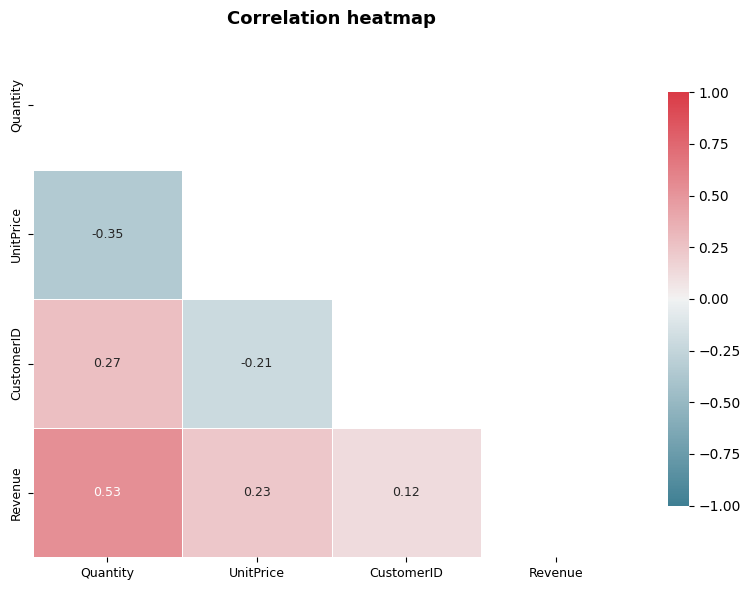

In [39]:
# Correlation heatmap 
fig, ax = plt.subplots(figsize=(8, 6))
num_df = df_capped.select_dtypes(include=np.number)
corr= num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation heatmap",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()